In [ ]:
# This imports the Pandas library, which I used to load, organize, clean, and analyze the dataset
import pandas as pd

In [17]:
# This imports Matplotlib and Seaborn, which I used to create charts and visualize patterns in the ocean data.
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# This loads the bottles.csv file into a Pandas DataFrame named df, allowing me to work with the data in Python.
df = pd.read_csv("bottles.csv")

In [ ]:
# This displays the entire DataFrame so I can preview its rows, columns, and values.
df

,Unnamed: 0,Depthm,T_degC,Salnty,O2ml_L,STheta
0,282769,0,16.810,33.6600,5.430,24.53100
1,657442,91,13.700,33.3240,5.740,24.95700
2,157944,9,12.400,33.5900,6.350,25.41900
3,45210,125,9.240,32.8850,5.290,25.42700
4,474774,30,16.330,35.1900,NaN,25.82000
...,...,...,...,...,...,...
995,234834,381,7.840,34.4200,NaN,26.84800
996,503295,41,13.760,33.4160,6.340,25.01500
997,165309,250,9.590,34.4840,NaN,26.62300
998,544600,250,8.770,34.1990,NaN,26.53200


In [ ]:
# This calculates summary statistics for selected columns, including the count, mean, standard deviation, minimum, maximum, and quartiles.
df[['Depthm','T_degC','Salnty','O2ml_L']].describe()

,Depthm,T_degC,Salnty,O2ml_L
count,1000.000000,987.000000,942.000000,799.000000
mean,234.267000,10.811239,33.820019,3.374533
std,345.483656,4.251855,0.569959,2.122412
min,0.000000,1.520000,24.421770,0.011000
25%,41.000000,7.520000,33.470250,1.175000
50%,125.000000,10.140000,33.877000,3.443000
75%,300.000000,13.965000,34.199750,5.485500
max,4400.000000,24.180000,35.670000,7.270000


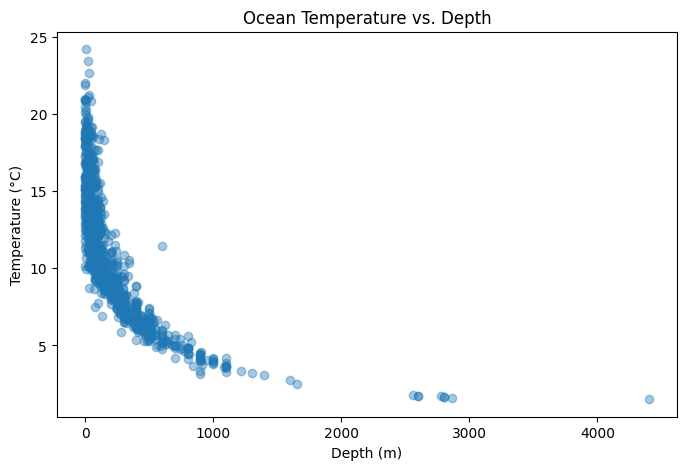

In [ ]:
# This creates a scatterplot comparing water depth with temperature. It helped reveal that temperature generally decreases as depth increases.
plt.figure(figsize=(8,5))
plt.scatter(df['Depthm'], df['T_degC'], alpha=0.4)
plt.xlabel("Depth (m)")
plt.ylabel("Temperature (°C)")
plt.title("Ocean Temperature vs. Depth")
plt.show()

In [ ]:
# This displays the number of records, column names, data types, and the number of nonmissing values in each column.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  1000 non-null   int64  
 1   Depthm      1000 non-null   int64  
 2   T_degC      987 non-null    float64
 3   Salnty      942 non-null    float64
 4   O2ml_L      799 non-null    float64
 5   STheta      934 non-null    float64
dtypes: float64(4), int64(2)
memory usage: 47.0 KB


In [ ]:
# This produces summary statistics for every numerical column in the dataset and helps identify ranges, variation, and possible outliers.
df.describe()

,Unnamed: 0,Depthm,T_degC,Salnty,O2ml_L,STheta
count,1000.000000,1000.000000,987.000000,942.000000,799.000000,934.000000
mean,442944.925000,234.267000,10.811239,33.820019,3.374533,25.811728
std,258928.705981,345.483656,4.251855,0.569959,2.122412,1.020912
min,1085.000000,0.000000,1.520000,24.421770,0.011000,23.216000
25%,212630.250000,41.000000,7.520000,33.470250,1.175000,24.967250
50%,442519.000000,125.000000,10.140000,33.877000,3.443000,25.993500
75%,673027.500000,300.000000,13.965000,34.199750,5.485500,26.664000
max,894687.000000,4400.000000,24.180000,35.670000,7.270000,27.785000


In [ ]:
# This counts the number of missing values in each column so I can determine which variables require cleaning.
df.isnull().sum()

,0
Unnamed: 0,0
Depthm,0
T_degC,13
Salnty,58
O2ml_L,201
STheta,66


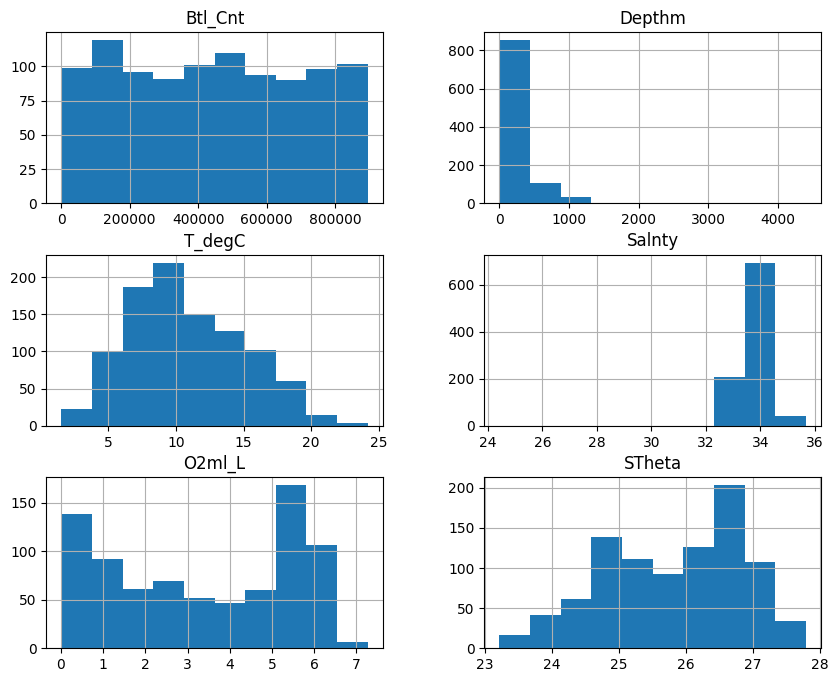

In [ ]:
# This creates a histogram for each numerical column, showing how the values are distributed throughout the dataset.
df.hist(figsize=(10,8))
plt.show()

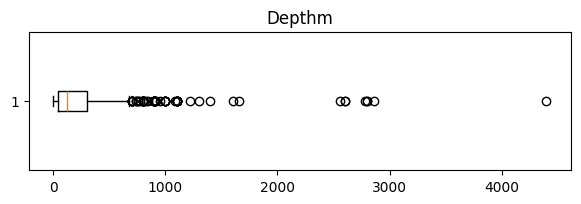

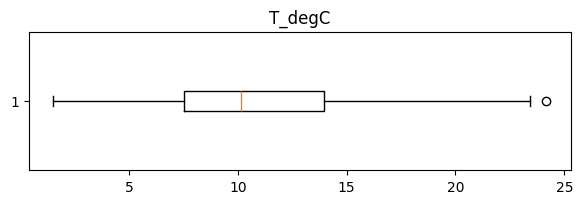

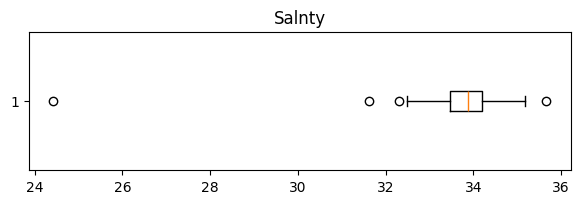

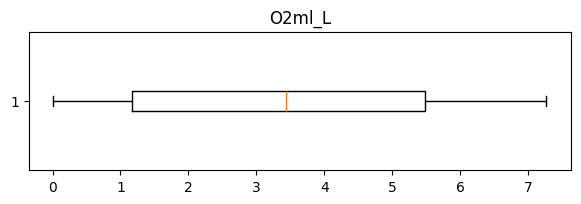

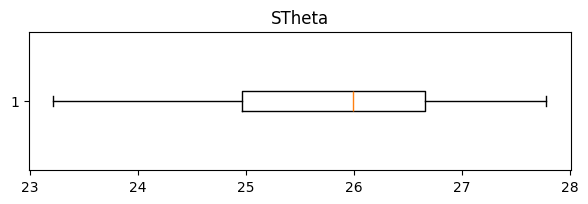

In [ ]:
# This loops through the selected columns and creates a separate boxplot for each one. The boxplots help identify the typical range of values and potential outliers.
cols = ['Depthm','T_degC','Salnty','O2ml_L','STheta']

for col in cols:
    plt.figure(figsize=(7,1.8))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(col)
    plt.show()

In [ ]:
# This uses the DataFrame’s shape to count and display how many columns are in the dataset. Not really needed but ran it to confirm.
print(f"The DataFrame `df` has {df.shape[1]} columns.")

The DataFrame `df` has 6 columns.


In [ ]:
# This loops through every column and displays the minimum and maximum values for numerical variables. It skips range calculations for nonnumerical columns.
# It helped me identify the scale of each feature and possible extreme values.
print("\n--- Range of Data in Each Column ---")
for column in df.columns:
    if pd.api.types.is_numeric_dtype(df[column]):
        min_val = df[column].min()
        max_val = df[column].max()
        print(f"Column: {column}, Min: {min_val}, Max: {max_val}")
    else:
        print(f"Column: {column}, (Non-numeric, no range to display)")


--- Range of Data in Each Column ---
Column: Btl_Cnt, Min: 1085, Max: 894687
Column: Depthm, Min: 0, Max: 4400
Column: T_degC, Min: 1.52, Max: 24.18
Column: Salnty, Min: 24.42177, Max: 35.67
Column: O2ml_L, Min: 0.011, Max: 7.27
Column: STheta, Min: 23.216, Max: 27.785


### Finding Outliers using the Interquartile Range (IQR) Method

The IQR method is a robust way to identify outliers. It defines outliers as any data points that fall outside of 1.5 times the IQR below the first quartile (Q1) or above the third quartile (Q3).

In [ ]:
# Let's take 'Depthm' as an example column to find outliers
# This uses the Interquartile Range method to identify unusually low or high depth values.
# I treated these as potential outliers rather than automatically deleting them because extreme depths may represent valid ocean measurements.
column_name = 'Depthm'

Q1 = df[column_name].quantile(0.25)
Q3 = df[column_name].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df[column_name] < lower_bound) | (df[column_name] > upper_bound)]

print(f"Outliers in '{column_name}' column (using IQR method):\n")
display(outliers[[column_name]])
print(f"\nNumber of outliers found in '{column_name}': {len(outliers)}")

Outliers in 'Depthm' column (using IQR method):



,Depthm
20,739
36,808
37,800
40,1000
66,826
...,...
933,900
964,1085
965,700
976,900



Number of outliers found in 'Depthm': 66


### Handling Missing Values: Imputation

Let's fill the missing values in `T_degC` and `Salnty` columns using the median. Median imputation is a good choice as it is less sensitive to outliers compared to mean imputation.

In [ ]:
# This calculates the median temperature and salinity values and uses them to replace missing entries in those columns.
# Impute 'T_degC' with its median
median_t_degc = df['T_degC'].median()
df['T_degC'] = df['T_degC'].fillna(median_t_degc)

# Impute 'Salnty' with its median
median_salnty = df['Salnty'].median()
df['Salnty'] = df['Salnty'].fillna(median_salnty)

print("Missing values after median imputation for 'T_degC' and 'Salnty':")
display(df.isnull().sum())

Missing values after median imputation for 'T_degC' and 'Salnty':


/tmp/ipykernel_691/3167758388.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['T_degC'].fillna(median_t_degc, inplace=True)
/tmp/ipykernel_691/3167758388.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

,0
Btl_Cnt,0
Depthm,0
T_degC,0
Salnty,0
O2ml_L,201
STheta,66


### Imputing Remaining Missing Values

Now, let's impute the missing values in `O2ml_L` and `STheta` using their respective medians.

### Imputing Remaining Missing Values

Now, let's impute the missing values in `O2ml_L` and `STheta` using their respective medians.

In [ ]:
# This calculates the median dissolved oxygen and potential density values and uses those medians to replace missing observations.
# Impute 'O2ml_L' with its median
median_o2ml_l = df['O2ml_L'].median()
df['O2ml_L'] = df['O2ml_L'].fillna(median_o2ml_l)

# Impute 'STheta' with its median
median_stheta = df['STheta'].median()
df['STheta'] = df['STheta'].fillna(median_stheta)

print("Missing values after median imputation for 'O2ml_L' and 'STheta':")
display(df.isnull().sum())

Missing values after median imputation for 'O2ml_L' and 'STheta':


,0
Btl_Cnt,0
Depthm,0
T_degC,0
Salnty,0
O2ml_L,0
STheta,0


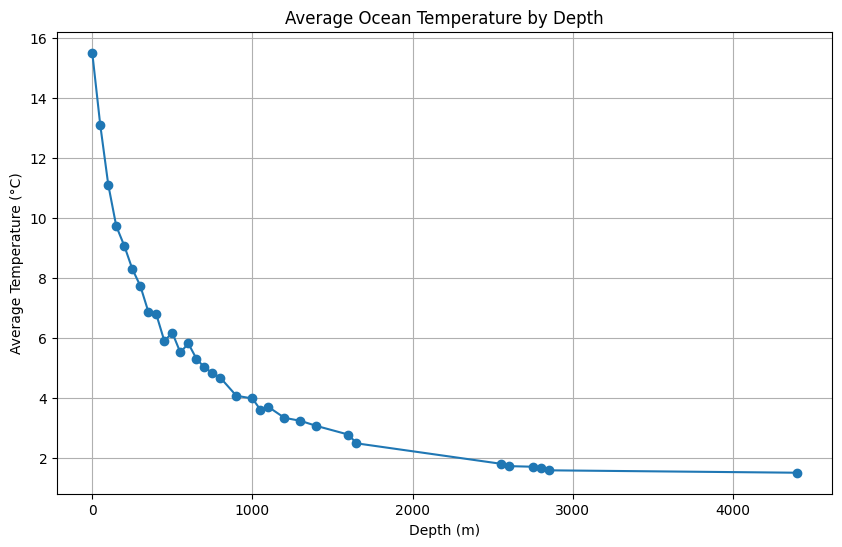

In [ ]:
# This creates a new column that groups individual depth measurements into 50-meter intervals.
# Create 50-meter depth bins
df['Depth_Bin'] = (df['Depthm'] // 50) * 50

# This groups the records by their 50-meter depth intervals and calculates the average temperature within each interval.
# Average temperature in each bin
avg_temp = df.groupby('Depth_Bin')['T_degC'].mean()

# This creates a line chart of average temperature at different depth intervals. It makes it easier to identify where the temperature changes most rapidly.
plt.figure(figsize=(10,6))
plt.plot(avg_temp.index, avg_temp.values, marker='o')
plt.xlabel("Depth (m)")
plt.ylabel("Average Temperature (°C)")
plt.title("Average Ocean Temperature by Depth")
plt.grid(True)
plt.show()

/tmp/ipykernel_2972/3237840142.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_temp.index, y=avg_temp.values, palette='viridis')


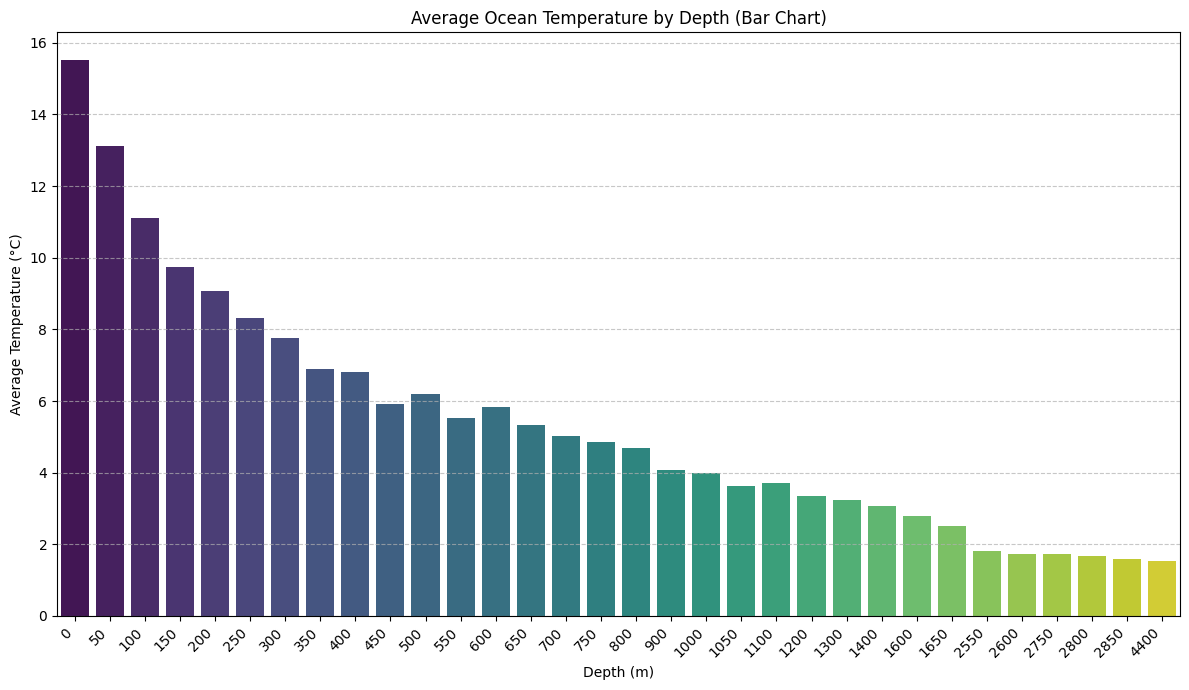

In [7]:
# This creates a bar chart comparing average temperature across the 50-meter depth intervals. Not really needed, I just wanted to see it in bar chart form.
plt.figure(figsize=(12, 7))
sns.barplot(x=avg_temp.index, y=avg_temp.values, palette='viridis')
plt.xlabel("Depth (m)")
plt.ylabel("Average Temperature (°C)")
plt.title("Average Ocean Temperature by Depth (Bar Chart)")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [13]:
# This selects water depth as the predictor variable and temperature as the target variable that the model will learn to predict.
# Predictor and target
X = df[['Depthm']]
y = df['T_degC']

In [14]:
# This checks whether any missing values remain in the predictor or target variables before training the model.
print(X.isnull().sum())
print(y.isnull().sum())

Depthm    0
dtype: int64
13


In [15]:
# This divides the dataset into training and testing portions.
# Eighty percent is used to teach the model, and the remaining 20% is used to evaluate its performance on unseen data.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# This displays how many observations were assigned to the training set and how many were reserved for testing.
print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 800
Testing records: 200


In [18]:
# This creates a filter that identifies valid temperature values and removes any remaining missing target values along with their corresponding depth records.
# Identify and remove NaN values from y_train and corresponding X_train rows
not_nan_mask = ~y_train.isna()
X_train_cleaned = X_train[not_nan_mask]
y_train_cleaned = y_train[not_nan_mask]

# This creates a linear regression model and trains it using the cleaned training data.
# The model learns the mathematical relationship between water depth and temperature.
model = LinearRegression()

# Fit the model using the cleaned data
model.fit(X_train_cleaned, y_train_cleaned)

# Note: It's recommended to re-check the imputation steps earlier in the notebook
# to ensure the original DataFrame columns are correctly updated, e.g.,
# df['T_degC'] = df['T_degC'].fillna(median_t_degc)

LinearRegression()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# This uses the trained model to predict temperatures for the depth observations in the testing set.
# Make predictions on the test set
y_pred = model.predict(X_test)

# This evaluates how closely the predicted temperatures match the actual temperatures using three performance measurements.
# Evaluate the model
# Mean Absolute Error shows how many degrees Celsius the predictions were off by on average.
mae = mean_absolute_error(y_test, y_pred)
# Mean Squared Error measures prediction error while giving greater weight to larger mistakes.
mse = mean_squared_error(y_test, y_pred)
# R-squared measures how much of the variation in temperature can be explained by water depth.
r2 = r2_score(y_test, y_pred)

# This displays each performance score rounded to two decimal places, making the model’s accuracy easier to interpret.
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

In [19]:
# This displays the two values used in the regression equation: the slope and the intercept. Since the slope is negative, the model predicts lower temps at greater depths.
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Slope: -0.0076887555571323795
Intercept: 12.582640210025392


In [20]:
y_pred = model.predict(X_test)

In [21]:
# This creates a comparison table showing the depth, actual measured temperature, and model-predicted temperature for each testing observation.
results = pd.DataFrame({
    'Depthm': X_test['Depthm'],
    'Actual_Temperature': y_test,
    'Predicted_Temperature': y_pred
})

results.head(10)

,Depthm,Actual_Temperature,Predicted_Temperature
521,169,9.318,11.283241
737,180,10.040,11.198664
740,0,13.900,12.582640
660,166,8.820,11.306307
411,100,9.100,11.813765
678,75,11.360,12.005984
626,492,5.660,8.799772
513,30,15.348,12.351978
859,500,6.250,8.738262
136,192,8.700,11.106399


In [ ]:
# Summary:

# Step 1: Loading and understanding the data

# I imported the required Python libraries, loaded the CSV file into a DataFrame, and reviewed its structure and summary statistics.


# Step 2: Exploratory analysis

# I used histograms, boxplots, ranges, and scatterplots to understand the variables, identify missing values, and investigate possible outliers.


# Step 3: Cleaning the data

# I used median imputation to replace missing values while reducing the influence of unusually high or low observations.


# Step 4: Refining the question

# I grouped depth into 50-meter intervals and calculated average temperature at each interval. The resulting line chart showed where the temperature decline was steepest.


# Step 5: Building and testing the model

# I divided the data into training and testing sets, trained a linear regression model, made predictions, and evaluated the results using MAE, MSE, and R-squared.


# I also used Gemini in Colab to help with writing some code